In [1]:
# import package
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import time
lib_dir = '/content/drive/MyDrive/Project/PlasticityDecoding'
os.chdir(lib_dir)
from modules.snn import *

dtype = torch.float64


In [2]:
# Check whether a GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [3]:
MNIST_data = np.load('/content/drive/MyDrive/Project/PlasticityDecoding/data/MNIST_data_500.npy',allow_pickle=True)
x_data = torch.tensor(MNIST_data.item().get('spk'), dtype=float, device=device, requires_grad=False)
y_data = torch.tensor(MNIST_data.item().get('type'), dtype=torch.long, device=device, requires_grad=False)
del MNIST_data

SRNN_args = {
    'nb_inputs':784,
    'nb_hidden':225,
    'nb_outputs':10,
    'tau_mem':500e-3, #10e-3
    'tau_syn':5e-3,
    'time_step':1e-3,
    'nb_steps':500,
    'device':device,
    'batch_size':300,
    'w_max':5e-3,
    'w_min':0,
    'x_tar':0.70,
    'act_noise':0.05,
    'weight_noise':5e-4,
    'bf_b':0.2,
    'burst_thres':4,
    'err2bf_scaling':0.2 * 0.3,
}


In [4]:
learning_epochs = 30
w_STDP = []
snn_STDP = SRNN(SRNN_args).to(device)
spk_rec_e, x_pre_rec = snn_STDP(x_data)

# Set firing rate baseline as the initial firing rate
if torch.rand(1) > 0.5:
    fr_baseline = 3
else:
    fr_baseline = 4

Spk_STDP_trace = []
Spk_STDP_tsp = []
STDP_lr = 4e-1
for epoch in range(0,learning_epochs):
    spk_rec_e, x_pre_rec = snn_STDP(x_data)
    snn_STDP = STDP(snn_STDP, SRNN_args, STDP_lr, spk_rec_e, x_pre_rec)
    spk_rec_e1 = event_2_burst(spk_rec_e, SRNN_args)
    Spk_STDP_tsp.append(torch.argwhere(spk_rec_e1 > 0))
    w_STDP.append(snn_STDP.state_dict()['w1'].clone())
fr_STDP = spk_rec_e1.detach().sum(dim=1)

if spk_rec_e1.detach().sum(dim=1).max() > 14:
    print('Firing rate too high!')


In [5]:
print(torch.argwhere(spk_rec_e1.detach().sum(dim=1) > 6))

tensor([[  3,   6],
        [ 23,   6],
        [ 39, 206],
        [ 77,   6],
        [147, 206],
        [151, 206],
        [152,  30],
        [157, 114],
        [174,  30],
        [174, 160],
        [209, 171],
        [215, 114],
        [235, 114],
        [249, 171],
        [269,  13],
        [290,  10],
        [291, 114]], device='cuda:0')


In [8]:
epoch_list = [11, 12, 29]

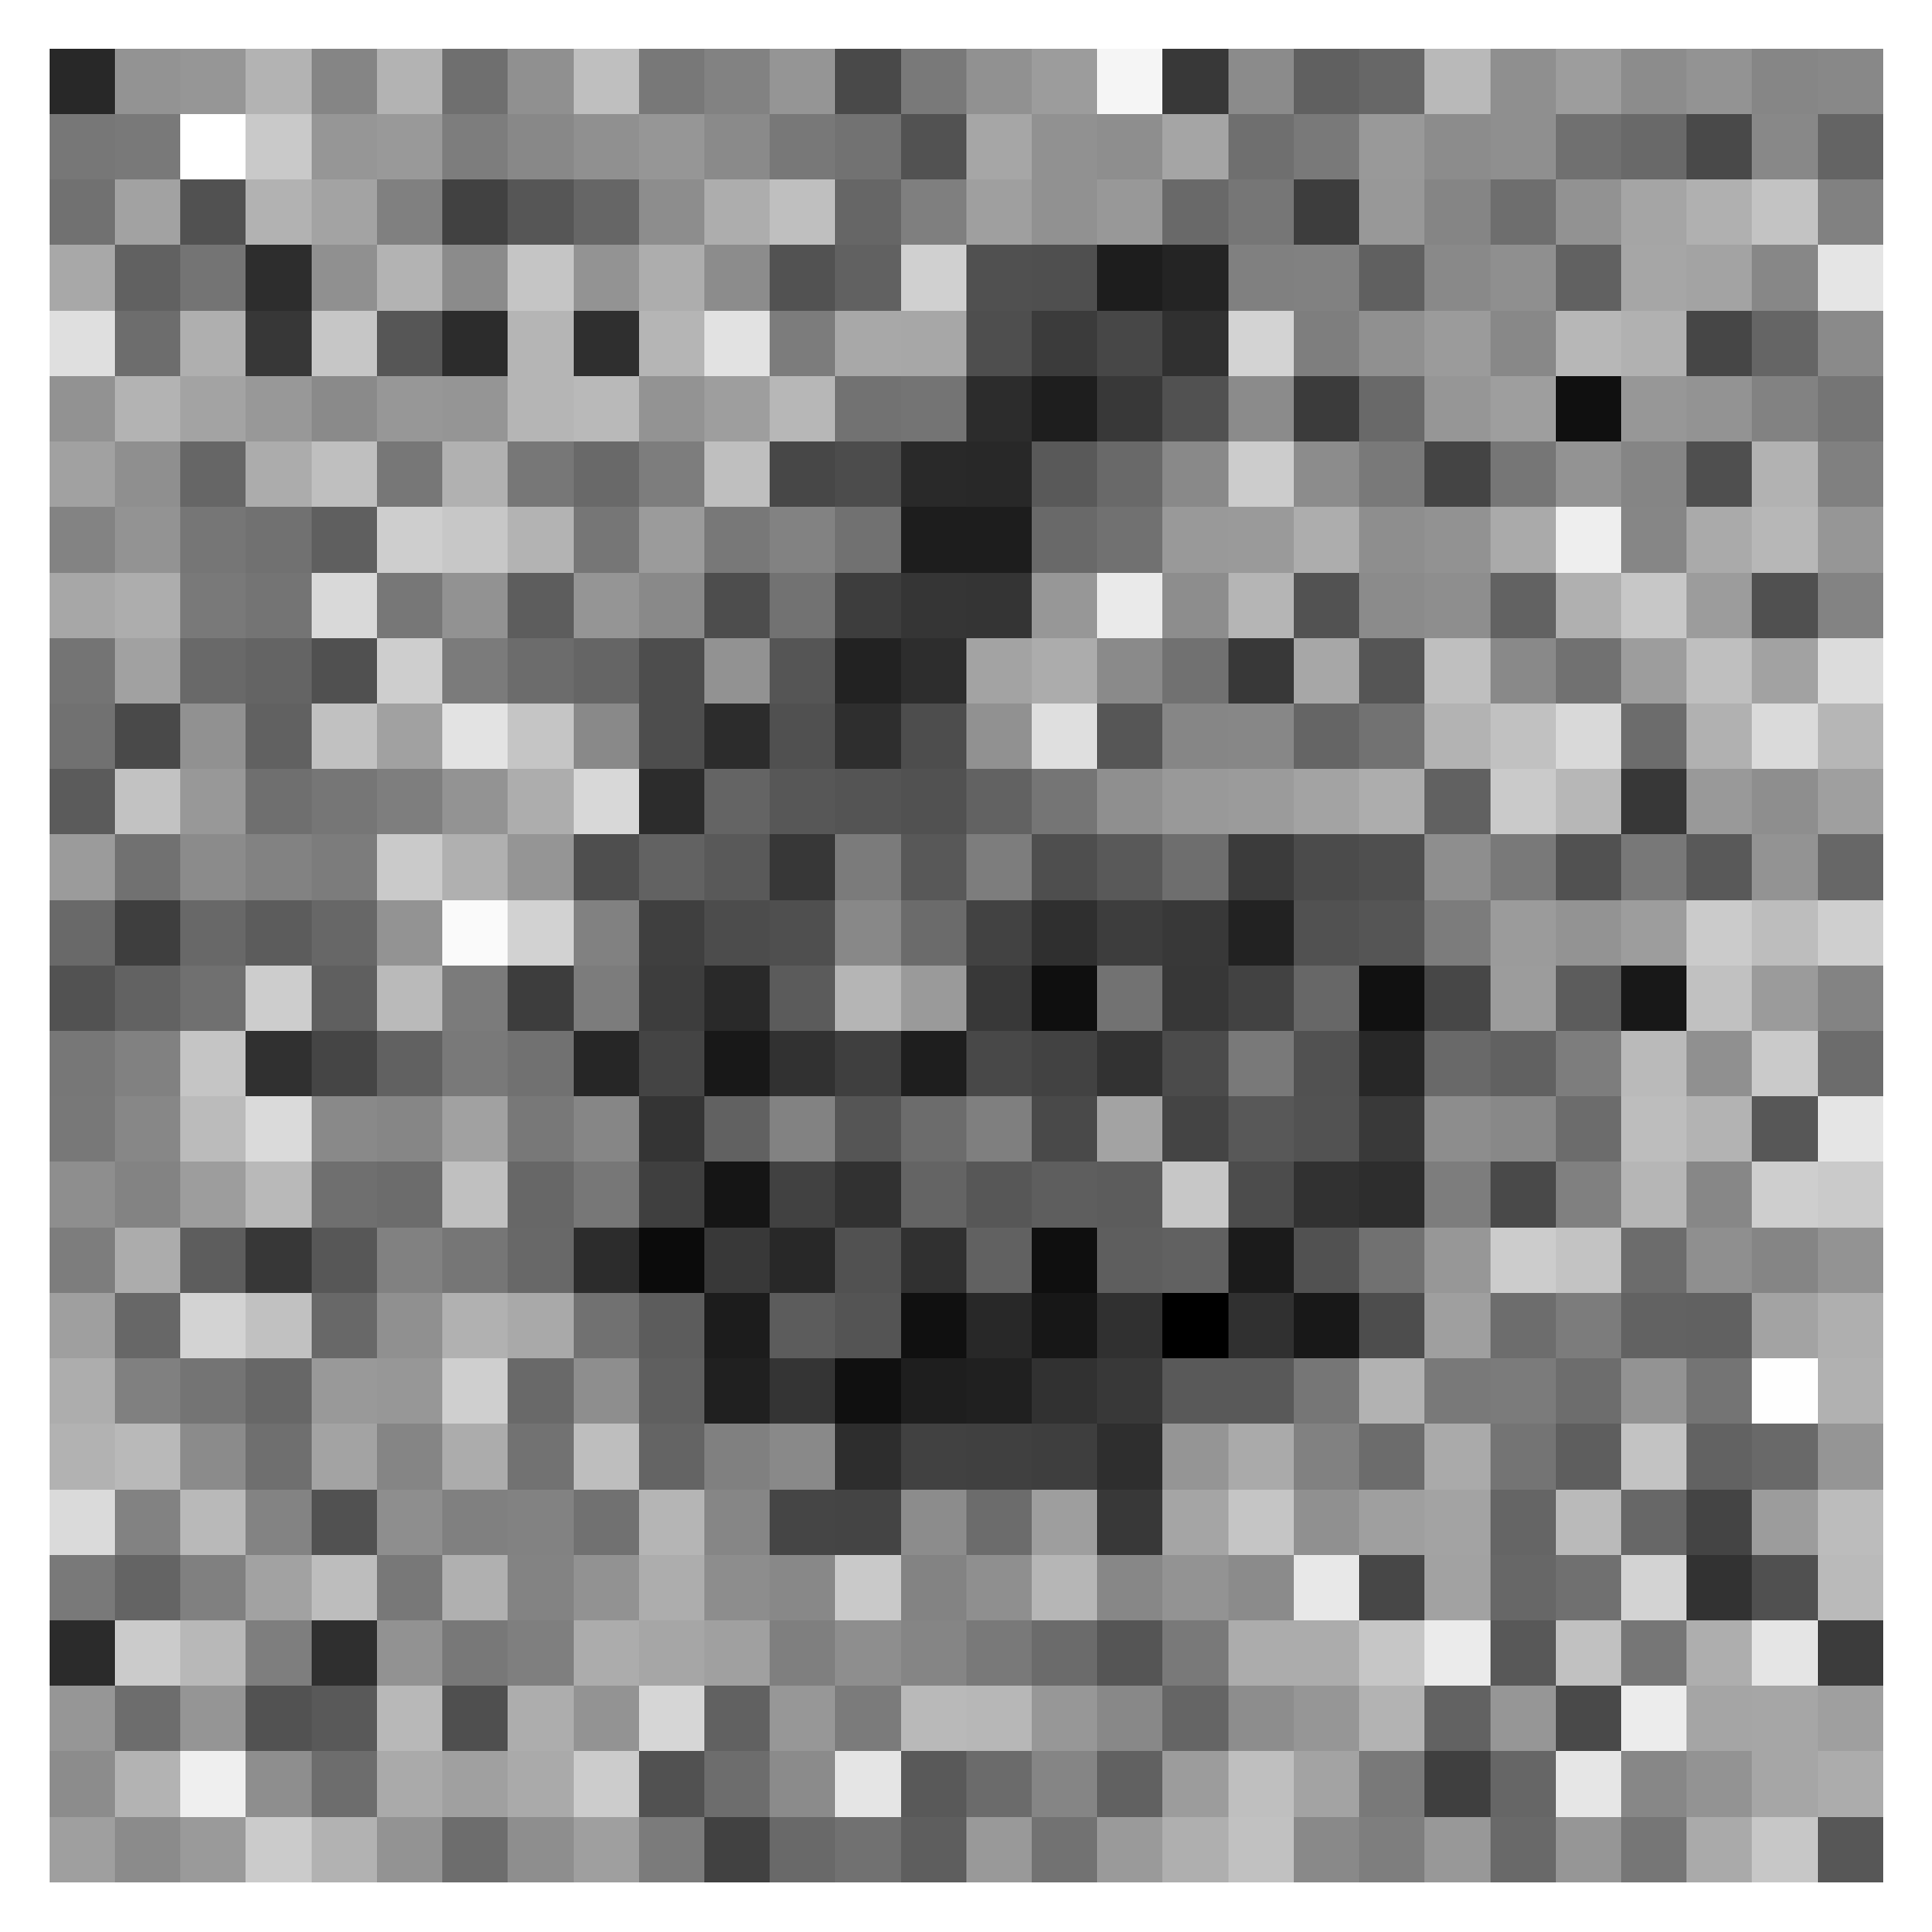

In [34]:
tune_ind = 206
epoch = 11
plt.figure(dpi=600)
plt.imshow(w_STDP[epoch][:,tune_ind].T.detach().cpu().numpy().reshape(28,28), cmap='gray_r')
plt.axis('off')
plt.show()